In [12]:
from functools import partial

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import optimize
from scipy.ndimage import convolve
from tqdm import tqdm

from spectrumlab.detectors import Detector
from spectrumlab.noises import ConstantNoise
from spectrumlab.peaks.analyte_peaks.shapes import PeakShape
from spectrumlab.peaks.analyte_peaks.shapes.retrieve_shape import retrieve_shape_from_spectrum
from spectrumlab.peaks.blink_peaks import DraftBlinksConfig, draft_blinks
from spectrumlab.spectra import EmittedSpectrum
from spectrumlab.types import Array, Number, R

from spectrumlab_emulations.apertures import Aperture, RectangularApertureShape
from spectrumlab_emulations.apparatus import Apparatus, VoigtApparatusShape
from spectrumlab_emulations.experiments.spectra_emulation import RandomPeakExperiment, RandomPeakExperimentConfig

from plugin.managers.process_manager.filters.scale_filter import estimate_alpha

In [13]:
def transformer(
    intensity: Array[R],
    background: Array[R],
    alpha: float = 0,
) -> Array[R]:
    assert len(intensity) == len(background)

    number = np.arange(len(intensity))
    index_even = number % 2 == 0
    index_odd = number % 2 == 1

    value = intensity.copy() + background.copy()
    value[index_even] = value[index_even] * (1 - alpha/2)
    value[index_odd] = value[index_odd] * (1 + alpha/2)
    return value


In [14]:
N_NUMBERS = 2048
N_FRAMES = 10
N_ITERS = 25

EXPOSURE = 100

SHAPE = VoigtApparatusShape(
    width=28,
    asymmetry=+0.1,
    ratio=0.1,
)

MU = -1
SIGMA = .5

In [15]:
ALPHA = 0.02


100%|██████████| 25/25 [00:00<00:00, 8332.61it/s]


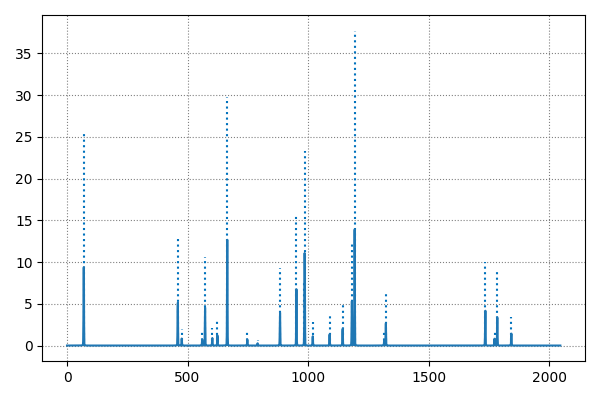

In [16]:
detector = Detector.BLPP2000

experiment = RandomPeakExperiment(
    config=RandomPeakExperimentConfig(
        n_numbers=N_NUMBERS,
        n_frames=N_FRAMES,

        detector=detector,
        apparatus=Apparatus(
            detector=detector,
            shape=SHAPE,
        ),
        aperture=Aperture(
            detector=detector,
            shape=RectangularApertureShape(),
        ),

        exposure=EXPOSURE,
        position=np.random.uniform(0, N_NUMBERS, size=(N_ITERS,)),
        intensity=10**np.random.normal(MU, SIGMA, size=(N_ITERS,)),
    ),
)
experiment = experiment.setup(
    # seed=42,
    verbose=True,
    show=True,
)

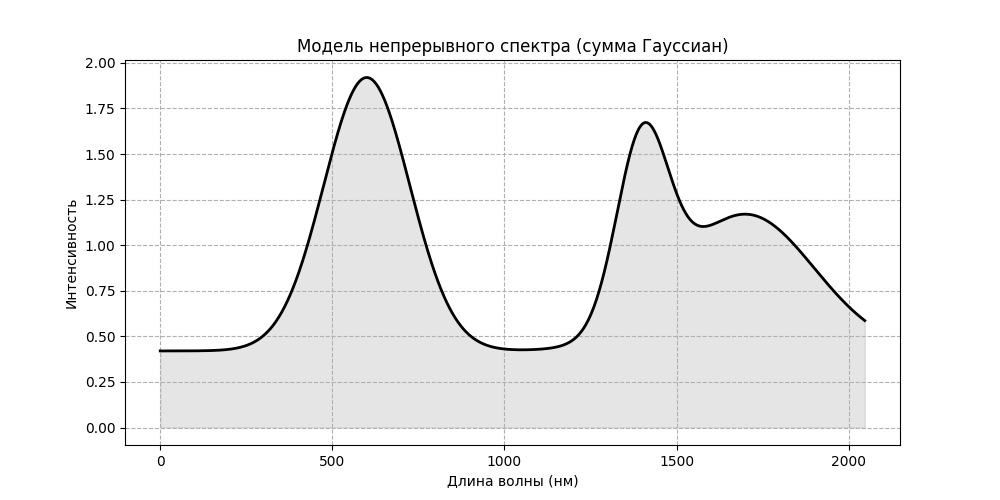

In [17]:
import numpy as np
import matplotlib.pyplot as plt

index = np.arange(N_NUMBERS)

params = [
    {"A": 2.5, "mu": 2500, "sigma": 75},
    {"A": 1.5, "mu": 600, "sigma": 125},
    {"A": 1, "mu": 1400, "sigma": 75},
    {"A": 0.75, "mu": 1700, "sigma": 200},
]

background = np.zeros(len(index), dtype=float) + .42

for p in params:
    line = p["A"] * np.exp(-((index - p["mu"])**2) / (2 * p["sigma"]**2))
    background += line


plt.figure(figsize=(10, 5))
plt.plot(index, background, label='Смоделированный спектр', color='black', lw=2)
plt.fill_between(index, background, alpha=0.2, color='gray')
plt.title("Модель непрерывного спектра (сумма Гауссиан)")
plt.xlabel("Длина волны (нм)")
plt.ylabel("Интенсивность")
plt.grid(True, linestyle='--')
plt.show()


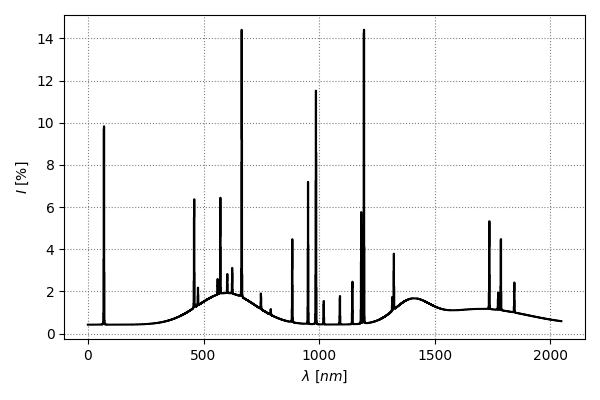

In [18]:
unicorn = experiment.run(
    is_noised=False,
    transformer=partial(transformer, background=background),
)
unicorn.show()


In [19]:
spectrum = experiment.run(
    is_noised=True,
    transformer=partial(transformer, alpha=ALPHA, background=background),
)

Peaks total: 48


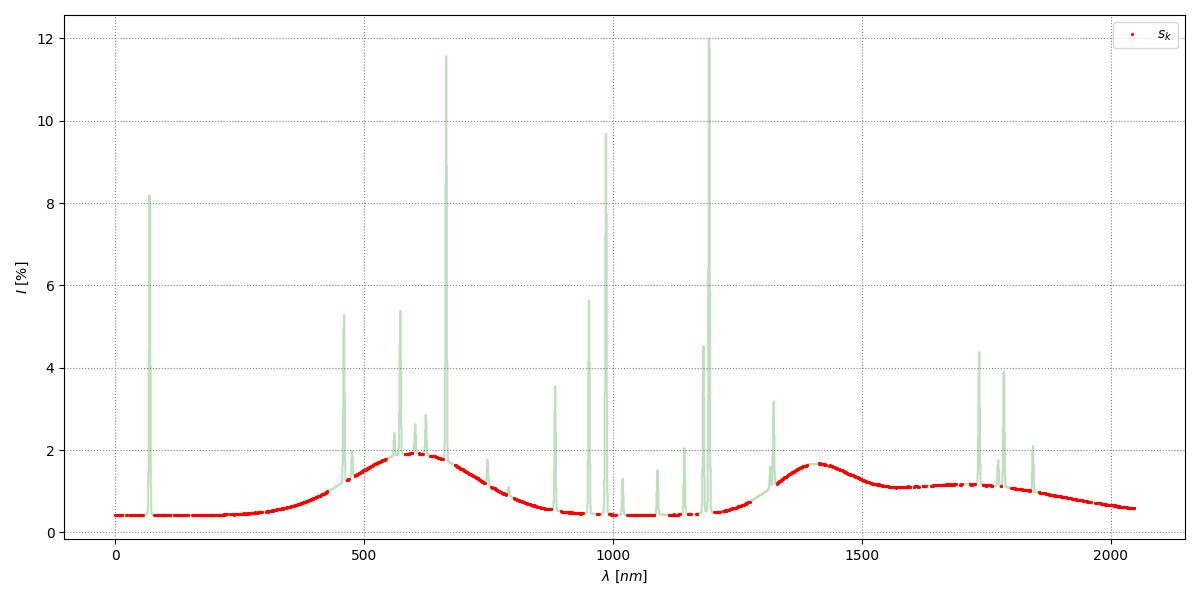

In [20]:
peaks = draft_blinks(
    spectrum=EmittedSpectrum(
        intensity=convolve(spectrum.intensity, [.25, .5, .25], mode='mirror'),
    ),
    config=DraftBlinksConfig(
        n_counts_min=3,
        except_clipped_peak=False,
        except_sloped_peak=True,
        except_edges=False,
        amplitude_min=.01,
        slope_max=1,
    ),
)
print('Peaks total: {}'.format(len(peaks)))

mask = np.full(spectrum.n_numbers, True)
for peak in peaks:
    lb, ub = peak.minima
    mask[lb:ub+1] = False

#
fig, ax = plt.subplots(figsize=(12, 6), tight_layout=True)

x = spectrum.wavelength
y = convolve(spectrum.intensity, [.25, .5, .25], mode='mirror')
ax.step(
    x, y,
    where='mid',
    color='green', alpha=.25,
)

x = spectrum.wavelength[mask]
y = convolve(spectrum.intensity, [.25, .5, .25], mode='mirror')[mask]
ax.plot(
    x, y,
    linestyle='none', color='red', alpha=1,
    marker='.', markersize=2.5,
    label='$s_{k}$',
)

ax.set_xlabel(r'$\lambda$ [$nm$]')
ax.set_ylabel(r'$I$ [$\%$]')
ax.grid(
    color='grey', linestyle=':',
)

ax.legend(loc='upper right')

plt.show()



In [ ]:
from spectrumlab.backgrounds.savitzky_golay_background import SavitzkyGolayBackgroundConfig, approximate_savitzky_golay


config = SavitzkyGolayBackgroundConfig(
    window=32,
    degree=2,
    n_counts_min=32,
    window_max=512,
)
background = approximate_savitzky_golay(
    convolve(spectrum.intensity, [.25, .5, .25], mode='mirror'),
    mask=~mask,
    config=config,
)

number = np.arange(len(spectrum.intensity))
index_even = number % 2 == 0
index_odd = number % 2 == 1

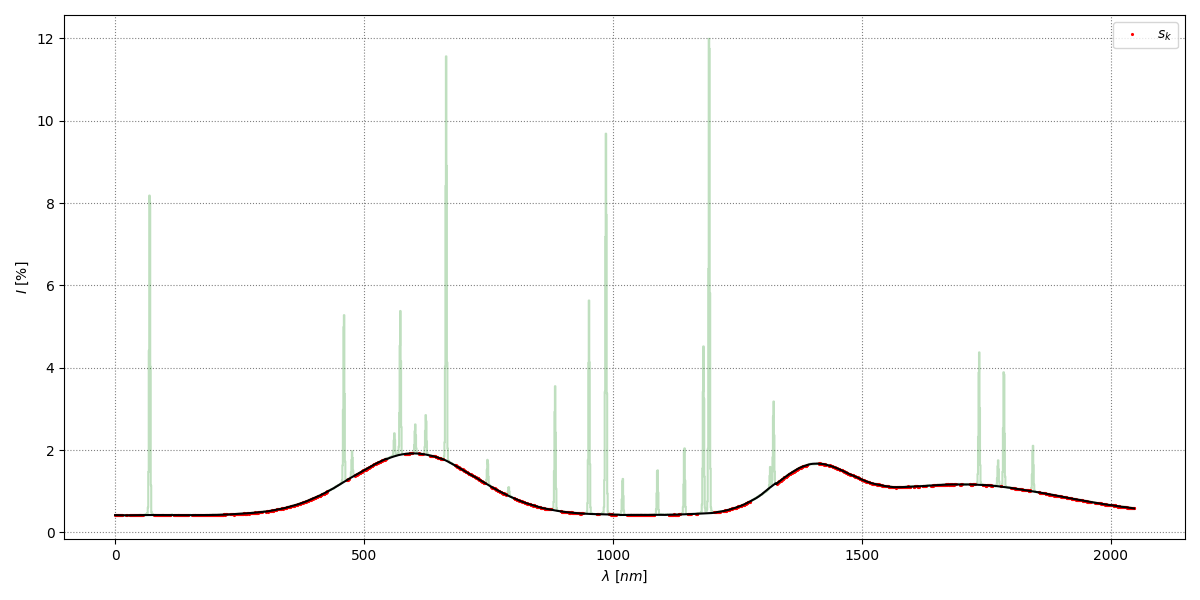

In [ ]:
%matplotlib widget



#
fig, ax = plt.subplots(figsize=(12, 6), tight_layout=True)

x = spectrum.wavelength
y = convolve(spectrum.intensity, [.25, .5, .25], mode='mirror')
ax.step(
    x, y,
    where='mid',
    color='green', alpha=.25,
)

x = spectrum.wavelength[mask]
y = convolve(spectrum.intensity, [.25, .5, .25], mode='mirror')[mask]
ax.plot(
    x, y,
    linestyle='none', color='red', alpha=1,
    marker='.', markersize=2.5,
    label='$s_{k}$',
)

x = spectrum.wavelength
y = background
ax.plot(
    x, y,
    color='black', alpha=1,
)

ax.set_xlabel(r'$\lambda$ [$nm$]')
ax.set_ylabel(r'$I$ [$\%$]')
ax.grid(
    color='grey', linestyle=':',
)

ax.legend(loc='upper right')

plt.show()


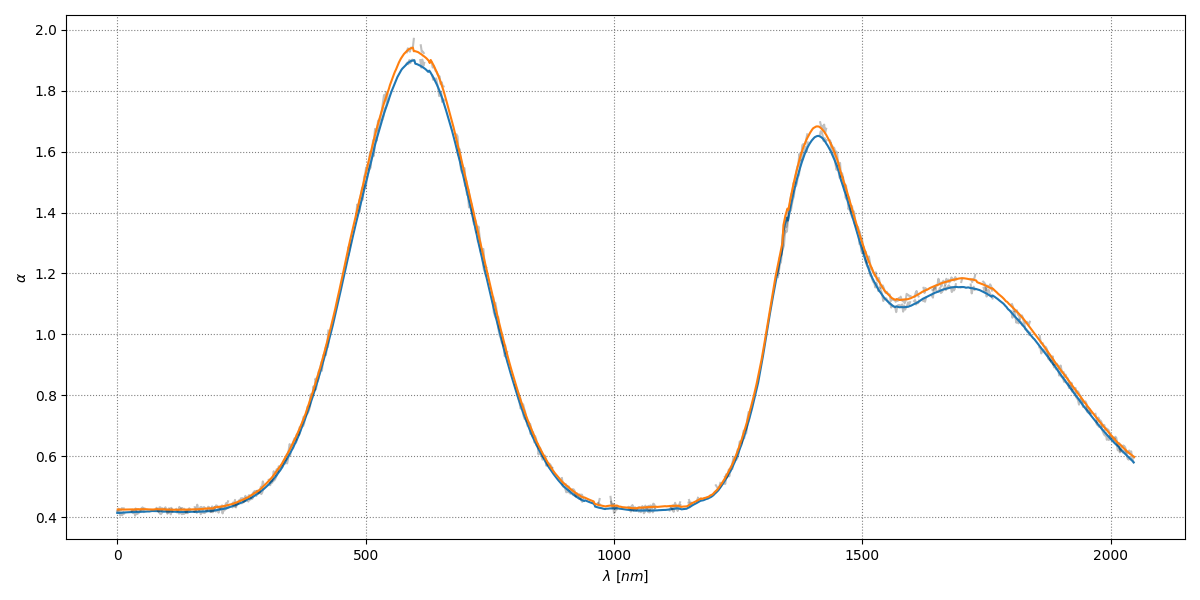

In [37]:

temp = spectrum.intensity[index_even]
temp[~mask[index_even]] = np.nan

intensity_even = spectrum.intensity[index_even]
intensity_even[~mask[index_even]] = np.nan
intensity_filled_even = approximate_savitzky_golay(
    intensity=temp,
    mask=~mask[index_even],
    config=config,
)

temp = spectrum.intensity[index_odd]
temp[~mask[index_odd]] = np.nan

intensity_odd = spectrum.intensity[index_odd]
intensity_odd[~mask[index_odd]] = np.nan
intensity_filled_odd = approximate_savitzky_golay(
    intensity=temp,
    mask=~mask[index_odd],
    config=config,
)


#
fig, ax = plt.subplots(figsize=(12, 6), tight_layout=True)

ax.plot(
    number[index_even], intensity_even,
    color='black', alpha=.25,
)
ax.plot(number[index_even], intensity_filled_even)
ax.plot(
    number[index_odd], intensity_odd,
    color='black', alpha=.25,
)
ax.plot(number[index_odd], intensity_filled_odd)

ax.set_xlabel(r'$\lambda$ [$nm$]')
ax.set_ylabel(r'$\alpha$')
ax.grid(color='grey', linestyle=':')

plt.show()

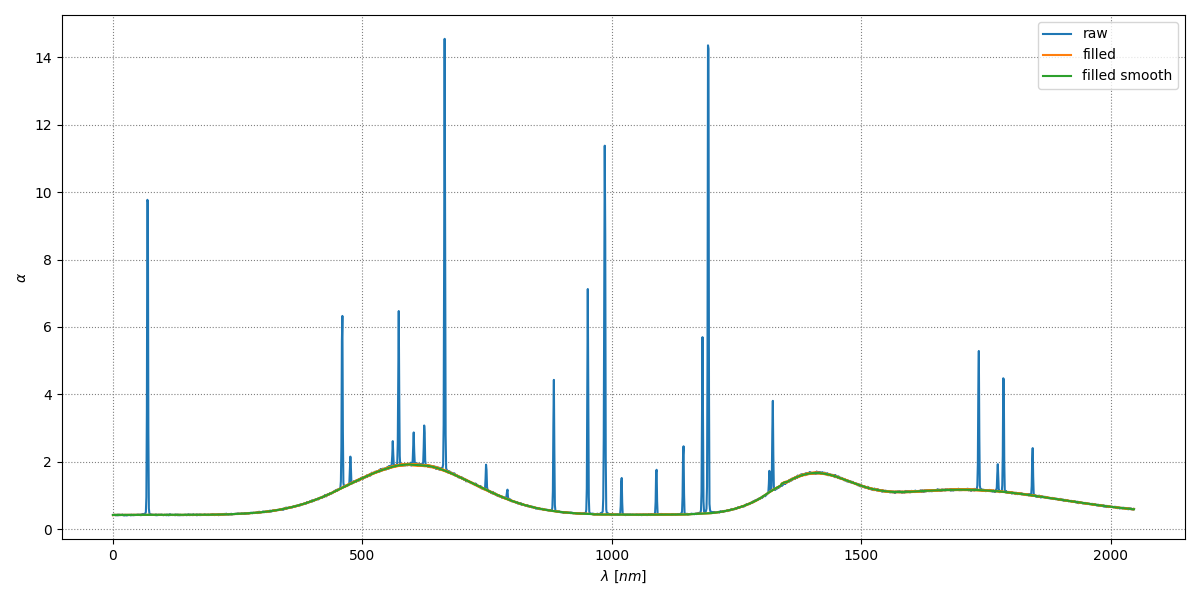

In [44]:
%matplotlib widget

intensity_filled = spectrum.intensity.copy()
intensity_filled[index_even] = intensity_filled_even
intensity_filled[index_odd] = intensity_filled_odd
intensity_filled_smooth = convolve(intensity_filled, [.25, .5, .25], mode='mirror')

#
fig, ax = plt.subplots(figsize=(12, 6), tight_layout=True)

ax.plot(spectrum.intensity, label='raw')
ax.plot(intensity_filled, label='filled')
ax.plot(intensity_filled_smooth, label='filled smooth')

ax.set_xlabel(r'$\lambda$ [$nm$]')
ax.set_ylabel(r'$\alpha$')
ax.grid(color='grey', linestyle=':')

plt.legend()
plt.show()


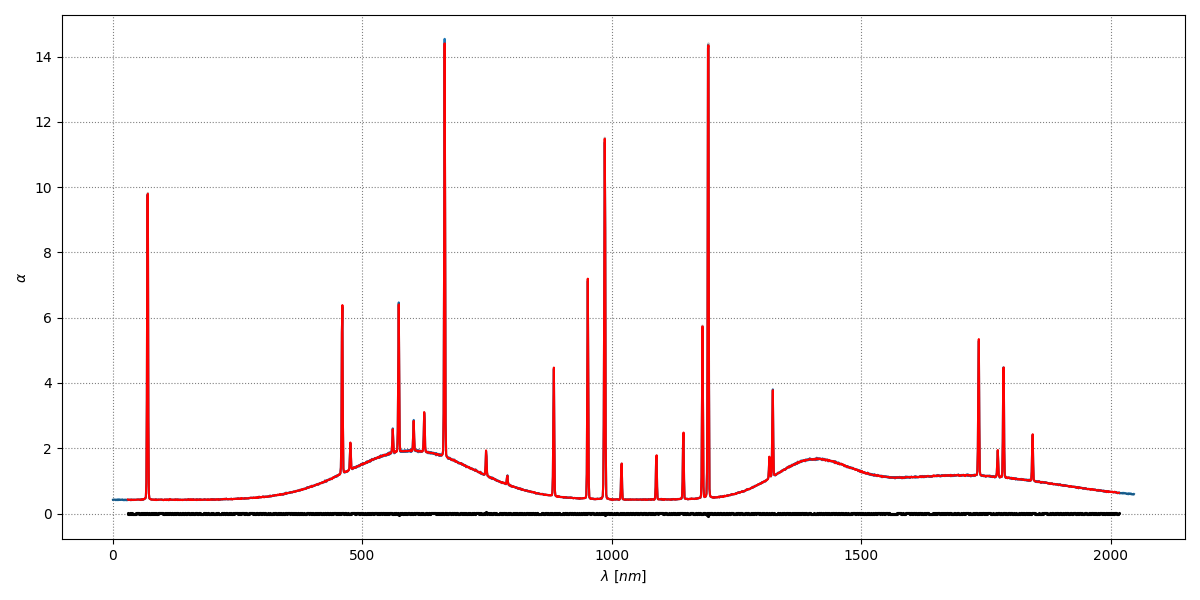

In [48]:
alpha_hat = intensity_filled / intensity_filled_smooth

alpha_hat_smooth = np.full(spectrum.n_numbers, 0.)
for index in [index_even, index_odd]:
    alpha_hat_smooth[index] = approximate_savitzky_golay(
        intensity=alpha_hat[index],
        mask=np.full(spectrum.n_numbers//2, False),
        config= SavitzkyGolayBackgroundConfig(
            window=32,
            degree=1,
        ),
    )


#
fig, ax = plt.subplots(figsize=(12, 6), tight_layout=True)

ax.plot(
    spectrum.wavelength,
    spectrum.intensity,
)
ax.plot(
    unicorn.wavelength,
    unicorn.intensity,
    color='black', alpha=.25,
)
ax.plot(
    spectrum.wavelength,
    spectrum.intensity / alpha_hat_smooth,
    color='red',
)

ax.plot(
    spectrum.wavelength,
    spectrum.intensity / alpha_hat_smooth - unicorn.intensity,
    linestyle='none', color='black', alpha=1,
    marker='.', markersize=2.5,
)

ax.set_xlabel(r'$\lambda$ [$nm$]')
ax.set_ylabel(r'$\alpha$')
ax.grid(color='grey', linestyle=':')

plt.show()

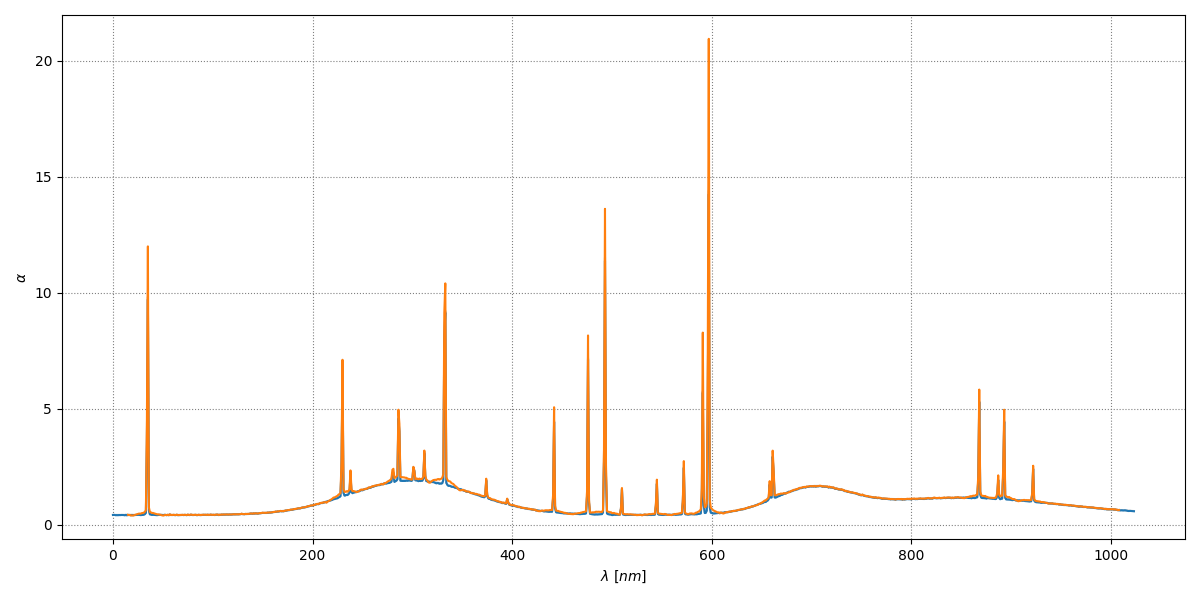

In [29]:
%matplotlib widget

intensity_filled = spectrum.intensity.copy()
intensity_filled[index_even] = intensity_filled_even

#
fig, ax = plt.subplots(figsize=(12, 6), tight_layout=True)

ax.plot(
    unicorn.intensity[index_even],
    color='black', alpha=.25,
)
ax.plot(spectrum.intensity[index_even])
# ax.plot(intensity_smooth[index_even])
ax.plot(spectrum.intensity[index_even] / approximate_savitzky_golay(
    intensity=alpha_hat[index_even],
    mask=np.full(spectrum.n_numbers//2, False),
    config= SavitzkyGolayBackgroundConfig(
        window=32,
        degree=2,
    ),
))
ax.set_xlabel(r'$\lambda$ [$nm$]')
ax.set_ylabel(r'$\alpha$')
ax.grid(color='grey', linestyle=':')

plt.show()


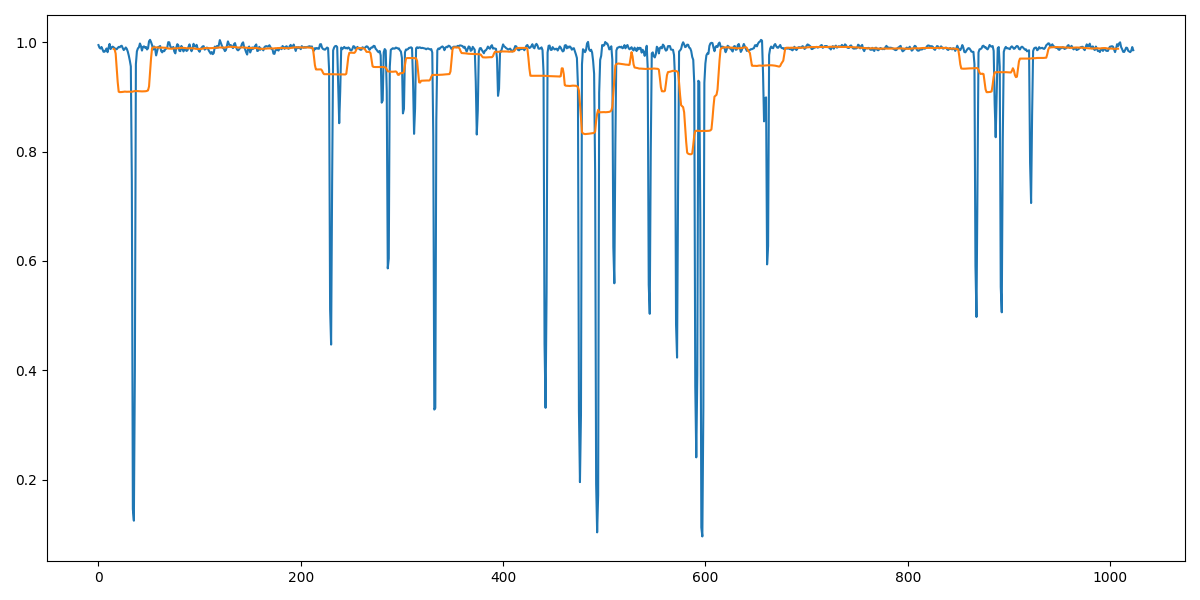

In [28]:
fig, ax = plt.subplots(figsize=(12, 6), tight_layout=True)

ax.plot(alpha_hat[index_even])
ax.plot(approximate_savitzky_golay(
    intensity=alpha_hat[index_even],
    mask=np.full(spectrum.n_numbers//2, False),
    config= SavitzkyGolayBackgroundConfig(
        window=32,
        degree=1,
    ),
))

In [ ]:
alpha_hat_smooth